In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import numpy as np
import matplotlib.pyplot as plt

from numba import njit
from tqdm import tqdm

@njit
def fast_diffusion(grid, size):
    """Numba-optimized stochastic diffusion with parallel processing."""
    new_grid = np.zeros_like(grid)
    
    # We parallelize the rows
    for r in range(size):
        for c in range(size):
            count = grid[r, c]
            if count == 0:
                continue
            
            # This inner loop is still sequential per core, 
            # but total throughput is much higher.
            for _ in range(count):
                move = np.random.randint(0, 5)
                if move == 0:
                    new_grid[r, c] += 1
                elif move == 1:
                    new_grid[(r - 1) % size, c] += 1
                elif move == 2:
                    new_grid[(r + 1) % size, c] += 1
                elif move == 3:
                    new_grid[r, (c - 1) % size] += 1
                else:
                    new_grid[r, (c + 1) % size] += 1
    return new_grid

@njit
def fast_enzyme_step(sucrose, glucose, fructose, levan, enz_pos, enz_full, size, rates):
    """Numba-optimized enzyme reaction loop."""
    # rates order: [S+LS, FLS+H20, FLS+S/F, FLS+Ln, LS+Ln/L1]
    for i in range(len(enz_pos)):
        # 1. Random Move Enzyme
        direction = np.random.randint(0, 6)
        if direction == 2:   # Up
            enz_pos[i, 0] = (enz_pos[i, 0] - 1) % size
        elif direction == 3: # Down
            enz_pos[i, 0] = (enz_pos[i, 0] + 1) % size
        elif direction == 4: # Left
            enz_pos[i, 1] = (enz_pos[i, 1] - 1) % size
        elif direction == 5:                # Right
            enz_pos[i, 1] = (enz_pos[i, 1] + 1) % size
        
        r, c = enz_pos[i, 0], enz_pos[i, 1]
        
        if not enz_full[i]:
            # Empty Enzyme Logic
            has_s = sucrose[r, c] > 0
            has_l = levan[r, c] > 1
            
            if has_s and has_l:
                total_rate = rates[0] + rates[4]
                if np.random.random() < (rates[0] / total_rate):
                    sucrose[r, c] -= 1
                    glucose[r, c] += 1
                    enz_full[i] = True
                else:
                    levan[r, c] -= 1
                    enz_full[i] = True
            elif has_s:
                sucrose[r, c] -= 1
                glucose[r, c] += 1
                enz_full[i] = True
            elif has_l:
                levan[r, c] -= 1
                enz_full[i] = True
        else:
            # Full Enzyme Logic
            w_hyd = rates[1]
            w_init_s = rates[2] if sucrose[r, c] > 0 else 0.0
            w_init_f = rates[2] if fructose[r, c] > 0 else 0.0
            w_growth = rates[3] if levan[r, c] > 0 else 0.0
            
            total_w = w_hyd + w_init_s + w_init_f + w_growth
            if total_w > 0:
                rand = np.random.random() * total_w
                if rand < w_hyd:
                    fructose[r, c] += 1
                    enz_full[i] = False
                elif rand < w_hyd + w_init_s:
                    sucrose[r, c] -= 1
                    levan[r, c] += 1
                    glucose[r, c] += 1
                    enz_full[i] = False
                elif rand < w_hyd + w_init_s + w_init_f:
                    fructose[r, c] -= 1
                    levan[r, c] += 1
                    enz_full[i] = False
                else:
                    levan[r, c] += 1
                    enz_full[i] = False

class LevanSimulation:
    def __init__(self, size=50, n_sucrose=1000000, n_enzyme=20, k_rates=[1, 1, 1, 1, 1]):
        self.size = size
        self.sucrose = np.zeros((size, size), dtype=np.int32)
        self.glucose = np.zeros((size, size), dtype=np.int32)
        self.fructose = np.zeros((size, size), dtype=np.int32)
        self.levan = np.zeros((size, size), dtype=np.int32)
        
        # Fast initialization
        for _ in range(n_sucrose):
            self.sucrose[np.random.randint(0, size), np.random.randint(0, size)] += 1
            
        # Numba-friendly Enzyme storage
        self.enz_pos = np.random.randint(0, size, size=(n_enzyme, 2))
        self.enz_full = np.zeros(n_enzyme, dtype=np.bool_)
        
        # Convert rates to float array for Numba
        self.rates = np.array(k_rates, dtype=np.float64)
        self.history = {'sucrose': [], 'glucose': [], 'fructose': [], 'levan_mass': [], 'full_e': []}

    def refill_sucrose(self, size=50, n_sucrose=5000):
        new_sucrose = np.zeros((size, size), dtype=np.int32)
        for _ in range(n_sucrose):
            new_sucrose[np.random.randint(0, size), np.random.randint(0, size)] += 1
        self.sucrose += new_sucrose

    def step(self):
        # 1. Diffusion (Calling the Numba functions)
        self.sucrose = fast_diffusion(self.sucrose, self.size)
        self.glucose = fast_diffusion(self.glucose, self.size)
        self.fructose = fast_diffusion(self.fructose, self.size)

        # 2. Reactions
        fast_enzyme_step(self.sucrose, self.glucose, self.fructose, self.levan, 
                         self.enz_pos, self.enz_full, self.size, self.rates)

        # 3. History
        self.history['sucrose'].append(self.sucrose.sum())
        self.history['glucose'].append(self.glucose.sum())
        self.history['fructose'].append(self.fructose.sum())
        self.history['levan_mass'].append(self.levan.sum())
        self.history['full_e'].append(self.enz_full.sum())

    # --- Helper Plotting ---
    def get_heatmap(self, data_source):
        """
        Adapted for Numba-optimized NumPy arrays.
        data_source can be a grid (sucrose/levan) or the string 'enzymes'.
        """
        # If the user asks for 'enzymes', we build the grid from enz_pos
        if isinstance(data_source, str) and data_source == 'enzymes':
            grid = np.zeros((self.size, self.size), dtype=np.int32)
            for i in range(len(self.enz_pos)):
                r, c = self.enz_pos[i]
                grid[r, c] += 1
            return grid
        
        # If it's already a substrate array, return it directly
        if isinstance(data_source, np.ndarray):
            return data_source
            
        return None

    def get_chain_lengths(self):
        """
        Returns all non-zero values from the levan grid.
        In the Numba version, this is still a 1D list of mass-per-pixel.
        """
        return self.levan[self.levan > 0].tolist()

def mean_concentration(simulation, v_cell=1.0):
    total_cells = simulation.size * simulation.size
    N_Avogadro = 6.022e23 
    
    # Conversion Factor to micromolar (uM)
    unit_conversion = (1 / N_Avogadro) * (1 / v_cell) * 1e6

    # 1. Sucrose Concentrations
    sucrose_conc = simulation.sucrose.flatten() * unit_conversion
    
    # 2. Enzyme Concentrations
    # Build the enzyme grid manually from the Numba-compatible array
    enzyme_grid = np.zeros((simulation.size, simulation.size), dtype=np.int32)
    for i in range(len(simulation.enz_pos)):
        r, c = simulation.enz_pos[i]
        enzyme_grid[r, c] += 1
    
    enzyme_conc = enzyme_grid.flatten() * unit_conversion

    # Stats Printout
    print(f"--- Statistics (Cell Volume: {v_cell:.2e} L) ---")
    print(f"Mean sucrose concentration: {np.mean(sucrose_conc):.2e} uM")
    print(f"Mean enzyme concentration: {np.mean(enzyme_conc):.2e} uM")

# --- Initialization & Execution ---
#k_rates = [519.59, 5, 1393.27, 2349.75]
k_rates = [15, 35, 20, 45, 1]

#sim = LevanSimulation(size=50, n_sucrose=1000000, n_enzyme=20, k_rates=k_rates)
sim = LevanSimulation(size=50, n_sucrose=5000, n_enzyme=20, k_rates=k_rates)
mean_concentration(sim, v_cell=8*10**(-20))

levan_distributions = []
#tmin = 10000
#tinterval = 10000
#tstep = 0.0005

tmin = 1000
tinterval = 1000
tstep = 0.0005


print("\n")
for i in tqdm(range(100000)):
    sim.step()
    if i%1000==0:
        sim.refill_sucrose()
    if i > tmin and i % tinterval == 0:
        levan_distributions.append(sim.get_chain_lengths())

--- Statistics (Cell Volume: 8.00e-20 L) ---
Mean sucrose concentration: 4.15e+01 uM
Mean enzyme concentration: 1.66e-01 uM




 93%|█████████▎| 92937/100000 [07:43<01:06, 106.02it/s]

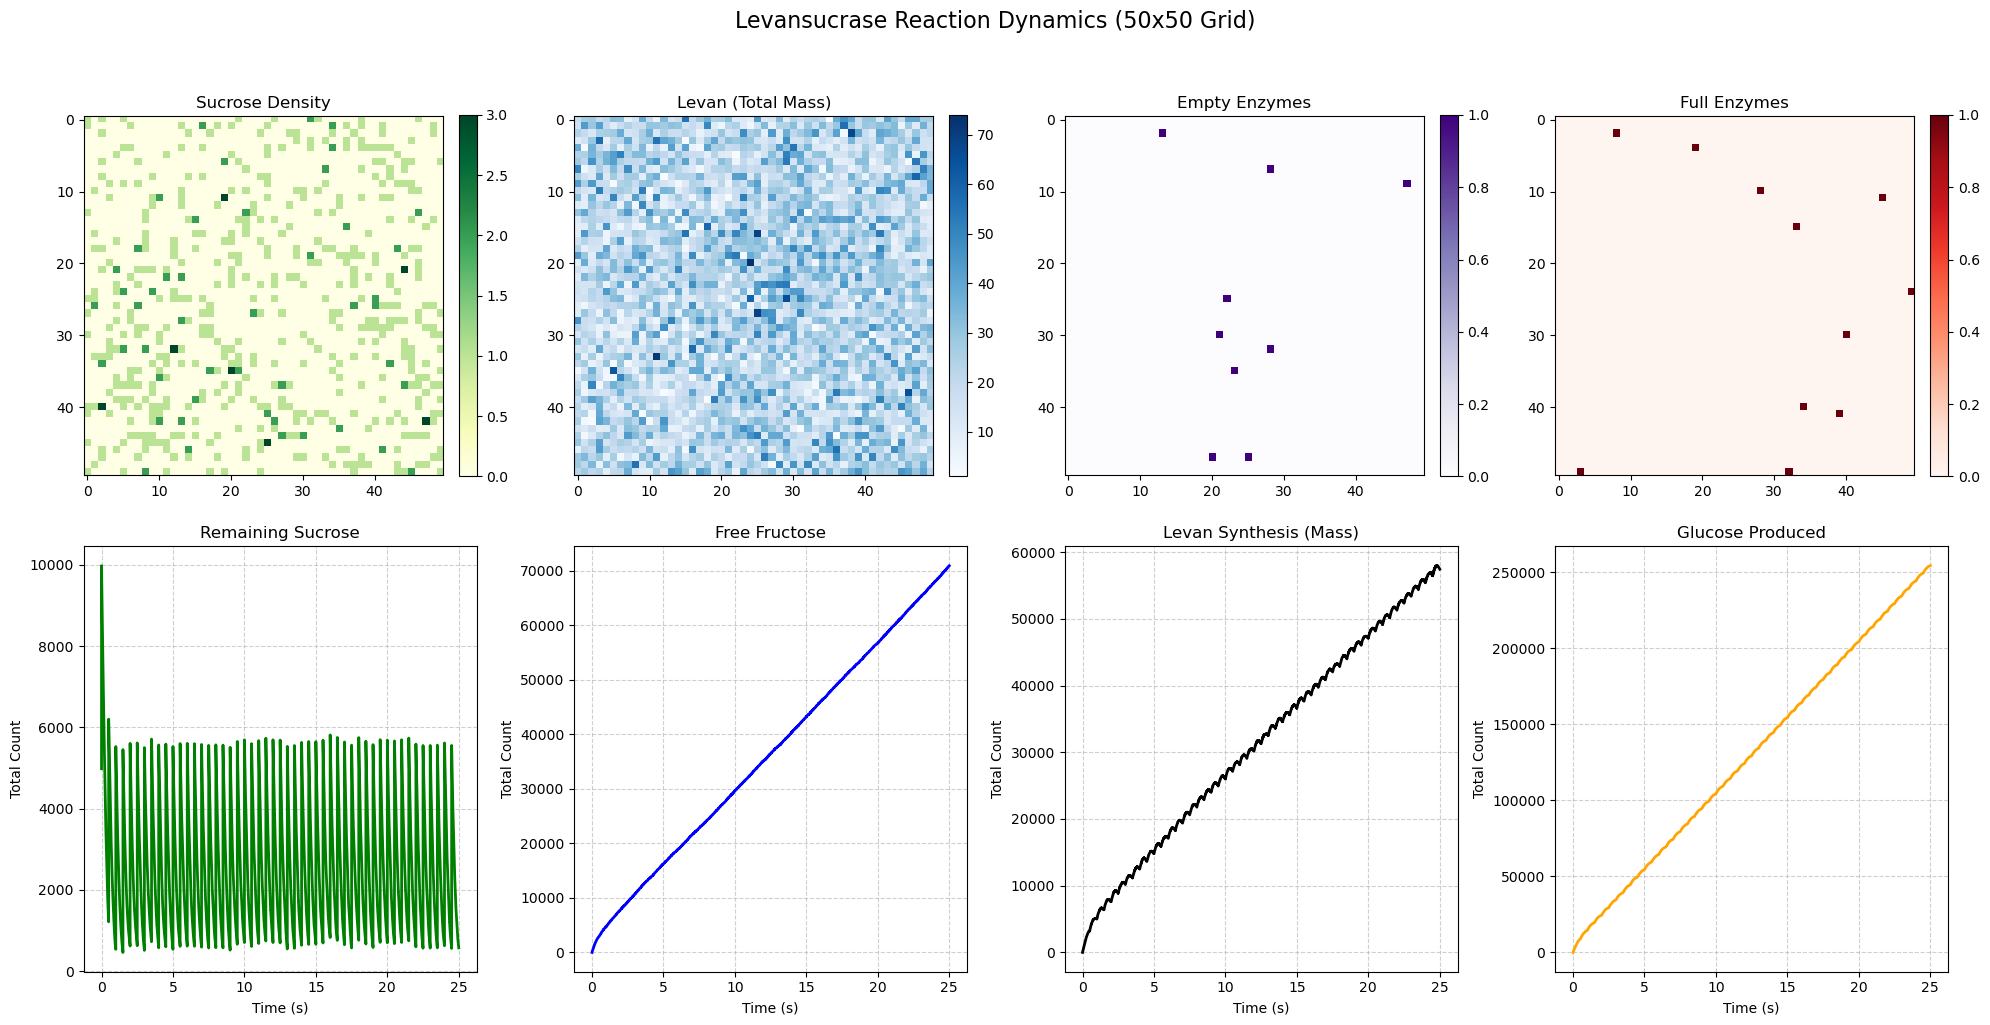

In [ ]:
# --- Visualization Dashboard Implementation ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# 1. Heatmaps
# Safety check: build the enzyme grids correctly for the dashboard
empty_enz_grid = np.zeros((sim.size, sim.size))
full_enz_grid = np.zeros((sim.size, sim.size))
for i in range(len(sim.enz_pos)):
    r, c = sim.enz_pos[i]
    if sim.enz_full[i]:
        full_enz_grid[r, c] += 1
    else:
        empty_enz_grid[r, c] += 1

heatmaps = [sim.sucrose, sim.levan, empty_enz_grid, full_enz_grid]
titles_top = ['Sucrose Density', 'Levan (Total Mass)', 'Empty Enzymes', 'Full Enzymes']
cmaps = ['YlGn', 'Blues', 'Purples', 'Reds']

for i in range(4):
    im = axes[0, i].imshow(heatmaps[i], cmap=cmaps[i], interpolation='nearest')
    axes[0, i].set_title(titles_top[i])
    fig.colorbar(im, ax=axes[0, i], fraction=0.046, pad=0.04)

# 2. Time Series
metrics = [
    ('sucrose', 'Green', 'Remaining Sucrose'),
    ('fructose', 'Blue', 'Free Fructose'),
    ('levan_mass', 'Black', 'Levan Synthesis (Mass)'),
    ('glucose', 'Orange', 'Glucose Produced')
]

for i, (key, color, label) in enumerate(metrics):
    data = np.array(sim.history[key])
    # Create time array that EXACTLY matches the data length
    current_time = np.arange(len(data)) * tstep 
    
    if len(data) > 0:
        axes[1, i].plot(current_time, data, color=color, lw=2)
    
    axes[1, i].set_title(label)
    axes[1, i].set_xlabel("Time (s)")
    axes[1, i].set_ylabel("Total Count")
    axes[1, i].grid(True, linestyle='--', alpha=0.6)

plt.suptitle(f"Levansucrase Reaction Dynamics ({sim.size}x{sim.size} Grid)", fontsize=16, y=1.02)
plt.tight_layout()

plt.savefig("Parameters_Refill.pdf")

plt.show()

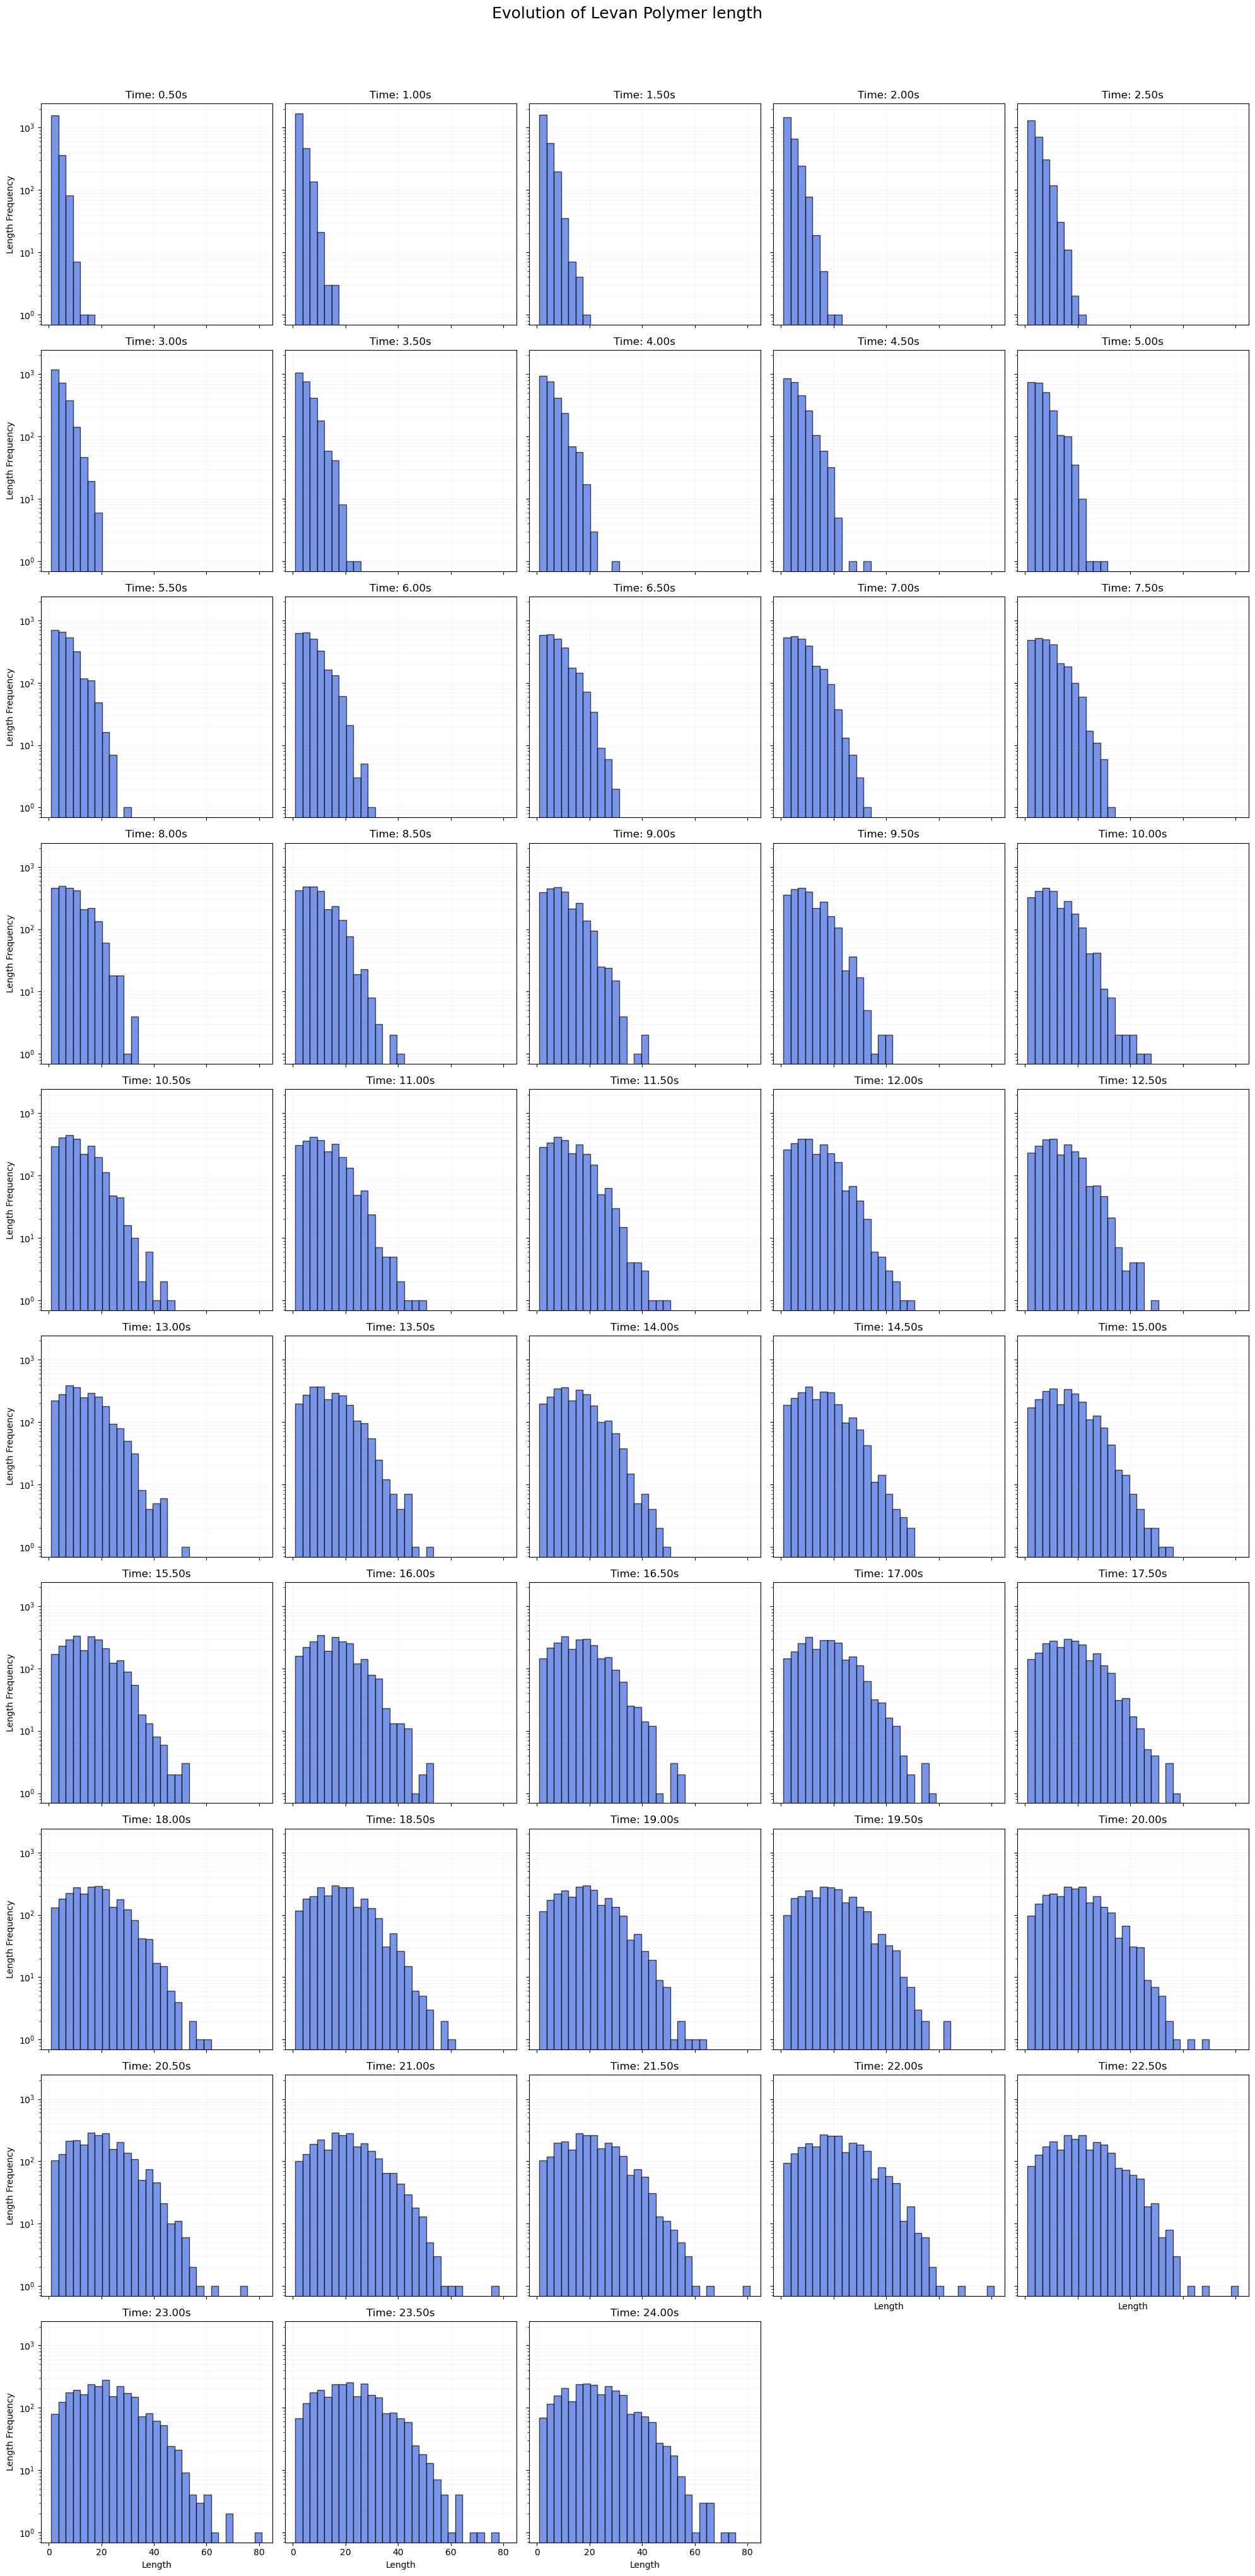

In [ ]:
# --- Evolution of Degree of Polymerization (DP) Dashboard ---

# 1. Determine the global maximum DP for consistent X-axes
# 'levan_distributions' contains lists of non-zero pixel values from sim.levan
if levan_distributions and any(dist for dist in levan_distributions):
    all_values = [val for dist in levan_distributions for val in dist]
    global_max = max(all_values)
else:
    all_values = []
    global_max = 10

# 2. Setup grid dimensions dynamically
num_plots = len(levan_distributions)
if num_plots == 0:
    print("No distribution data collected yet. Run more steps!")
else:
    cols = 5
    rows = int(np.ceil(num_plots / cols))

    # Adjust figsize: 4x4 inches per subplot is usually a good balance
    fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows), squeeze=False, sharex=True, sharey=True)
    axes = axes.flatten()

    for i, dist in enumerate(levan_distributions):
        ax = axes[i]
        
        # Calculate the actual time for this snapshot
        current_time_step = tmin + (i * tinterval)
        actual_time_sec = current_time_step * tstep
        
        if len(dist) > 0:
            # We use a log scale because levan mass often varies by orders of magnitude
            # across different pixels as the reaction progresses.
            bins = np.linspace(1, global_max + 1, 30) # 30 bins for smoother look
            
            ax.hist(dist, bins=bins, color='royalblue', alpha=0.7, edgecolor='black')
            
            ax.set_yscale('log')

            # Metadata
            ax.set_title(f"Time: {actual_time_sec:.2f}s")
            ax.grid(True, which="both", ls="-", alpha=0.1)
        else:
            ax.text(0.5, 0.5, "No Levan Produced", ha='center', va='center', transform=ax.transAxes)

        # Labeling logic
        if i % cols == 0:
            ax.set_ylabel("Length Frequency")
        if i >= num_plots - cols:
            ax.set_xlabel("Length")

    # 3. Hide any unused axes
    for j in range(num_plots, len(axes)):
        axes[j].axis('off')

    plt.suptitle("Evolution of Levan Polymer length", fontsize=18, y=1.02)
    plt.tight_layout()

    plt.savefig("Distributions_Refill.pdf")

    plt.show()